In [32]:
import math
import rasterio
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import geopandas as gpd
from pathlib import Path
import seaborn as sns

In [33]:
# Configure plotting style
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (14, 10)
plt.rcParams["font.size"] = 10

OUTPUT_DIR = Path("./figures")
OUTPUT_DIR.mkdir(exist_ok=True)

LAYERS_DIR = Path("./data/silver/layers")
BOUNDARY_PATH = LAYERS_DIR / "boundary.shp"

In [34]:
# Assuming BOUNDARY_PATH, LAYERS_DIR, and OUTPUT_DIR are already defined globally

def plot_raster_group(var_list, group_title, filename_prefix):
    """
    Dynamically generates maps for a list of spatial variables.
    
    Parameters:
    - var_list: List of tuples (filename, title, colormap)
    - group_title: Overall title for the figure
    - filename_prefix: Used for the saved output image name
    """
    boundary = gpd.read_file(BOUNDARY_PATH).to_crs("EPSG:27700")
    
    # Calculate grid dimensions dynamically
    n_vars = len(var_list)
    cols = 2
    rows = math.ceil(n_vars / cols)
    
    # Adjust figure size based on number of rows
    fig = plt.figure(figsize=(16, 5 * rows))
    gs = GridSpec(rows, cols, figure=fig, hspace=0.35, wspace=0.25)

    for idx, (filename, title, cmap) in enumerate(var_list):
        ax = fig.add_subplot(gs[idx])
        path = LAYERS_DIR / filename

        if not path.exists():
            ax.text(0.5, 0.5, f"{filename}\nnot found", ha="center", va="center",
                    transform=ax.transAxes, fontsize=11, color="red")
            ax.set_title(title, fontsize=12, fontweight="bold")
            ax.axis('off')
            continue

        with rasterio.open(path) as src:
            data = src.read(1)
            bounds = src.bounds

        # Plot
        im = ax.imshow(data, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
                       cmap=cmap, interpolation="nearest", origin="upper")
        boundary.boundary.plot(ax=ax, color="black", linewidth=1.5)

        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        # Safely extract units for colorbar if present in parentheses
        cbar_label = title.split("(")[1].rstrip(")") if "(" in title else "Value"
        cbar.set_label(cbar_label, fontsize=9)

        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("Easting (m)", fontsize=8)
        ax.set_ylabel("Northing (m)", fontsize=8)
        ax.tick_params(labelsize=7)

    # Turn off axes for any empty subplots if n_vars is odd
    for idx in range(n_vars, rows * cols):
        fig.add_subplot(gs[idx]).axis("off")

    fig.suptitle(group_title, fontsize=16, fontweight="bold", y=1.02 - (0.02 * rows))
    
    output_path = OUTPUT_DIR / f"{filename_prefix}.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {output_path.name}")
    
    # Use plt.show() so it renders neatly in the notebook
    plt.show()

Saved: 04_topo_maps.png


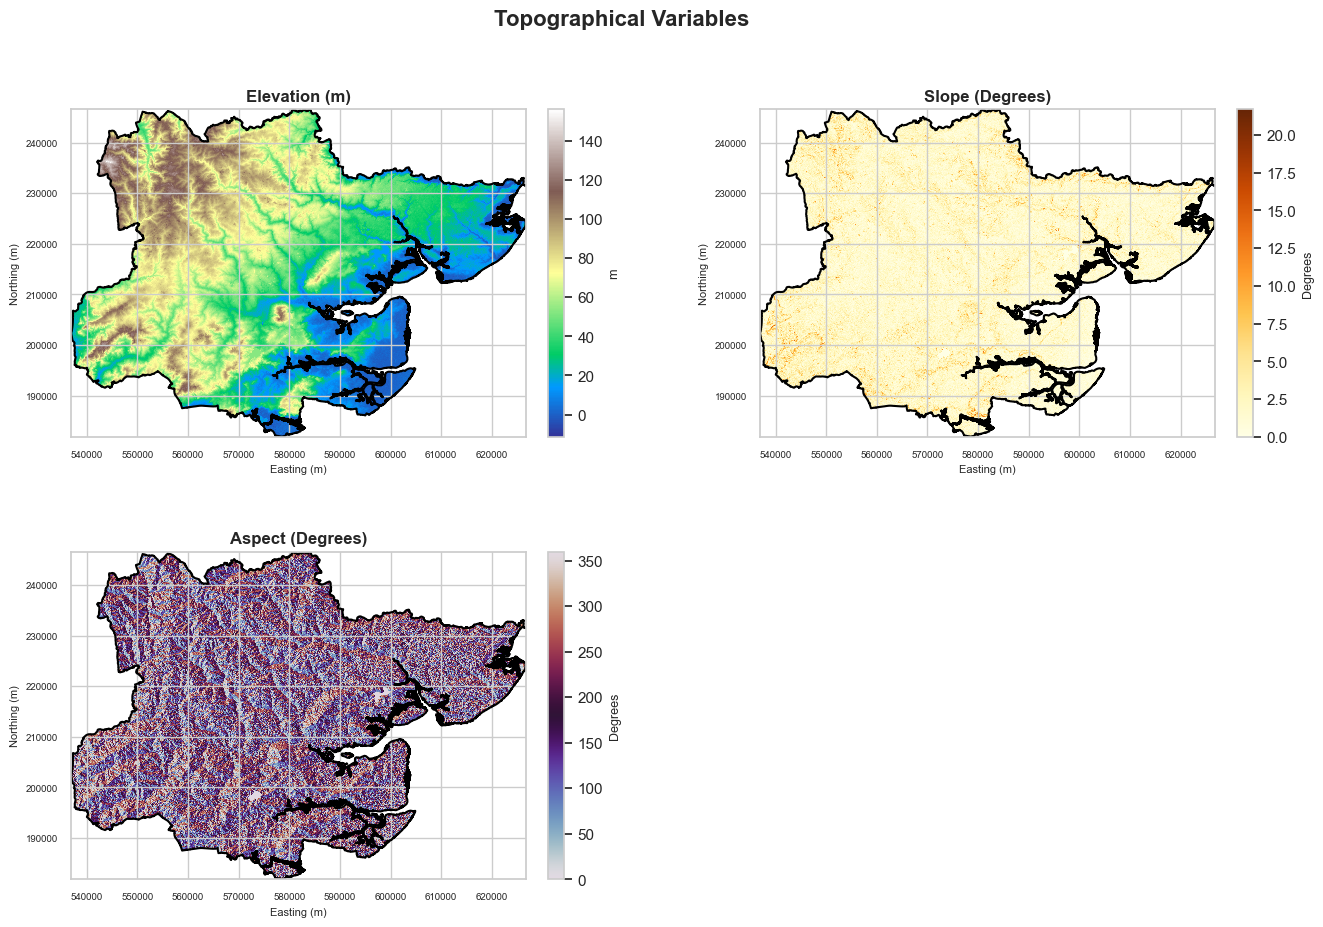

In [35]:
topo_vars = [
    ("topo_elevation.tif", "Elevation (m)", "terrain"),
    ("topo_slope.tif", "Slope (Degrees)", "YlOrBr"),
    ("topo_aspect.tif", "Aspect (Degrees)", "twilight")
]

plot_raster_group(topo_vars, "Topographical Variables", "04_topo_maps")

Saved: 05_dist_maps.png


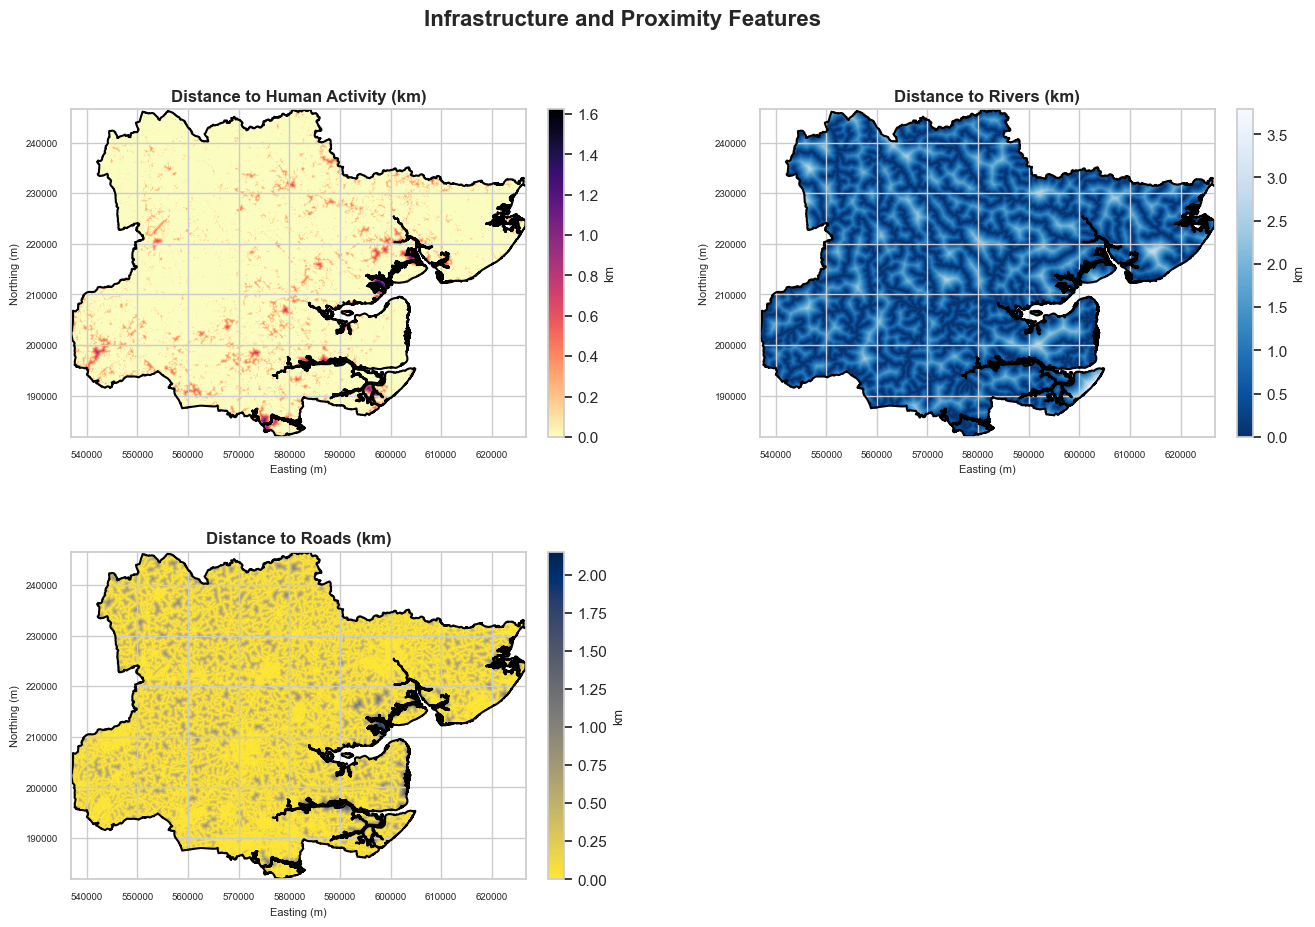

In [36]:
dist_vars = [
    ("dist_activity.tif", "Distance to Human Activity (km)", "magma_r"),
    ("dist_rivers.tif", "Distance to Rivers (km)", "Blues_r"),
    ("dist_roads.tif", "Distance to Roads (km)", "cividis_r")
]

plot_raster_group(dist_vars, "Infrastructure and Proximity Features", "05_dist_maps")

Saved: 03_climate_maps_summer.png


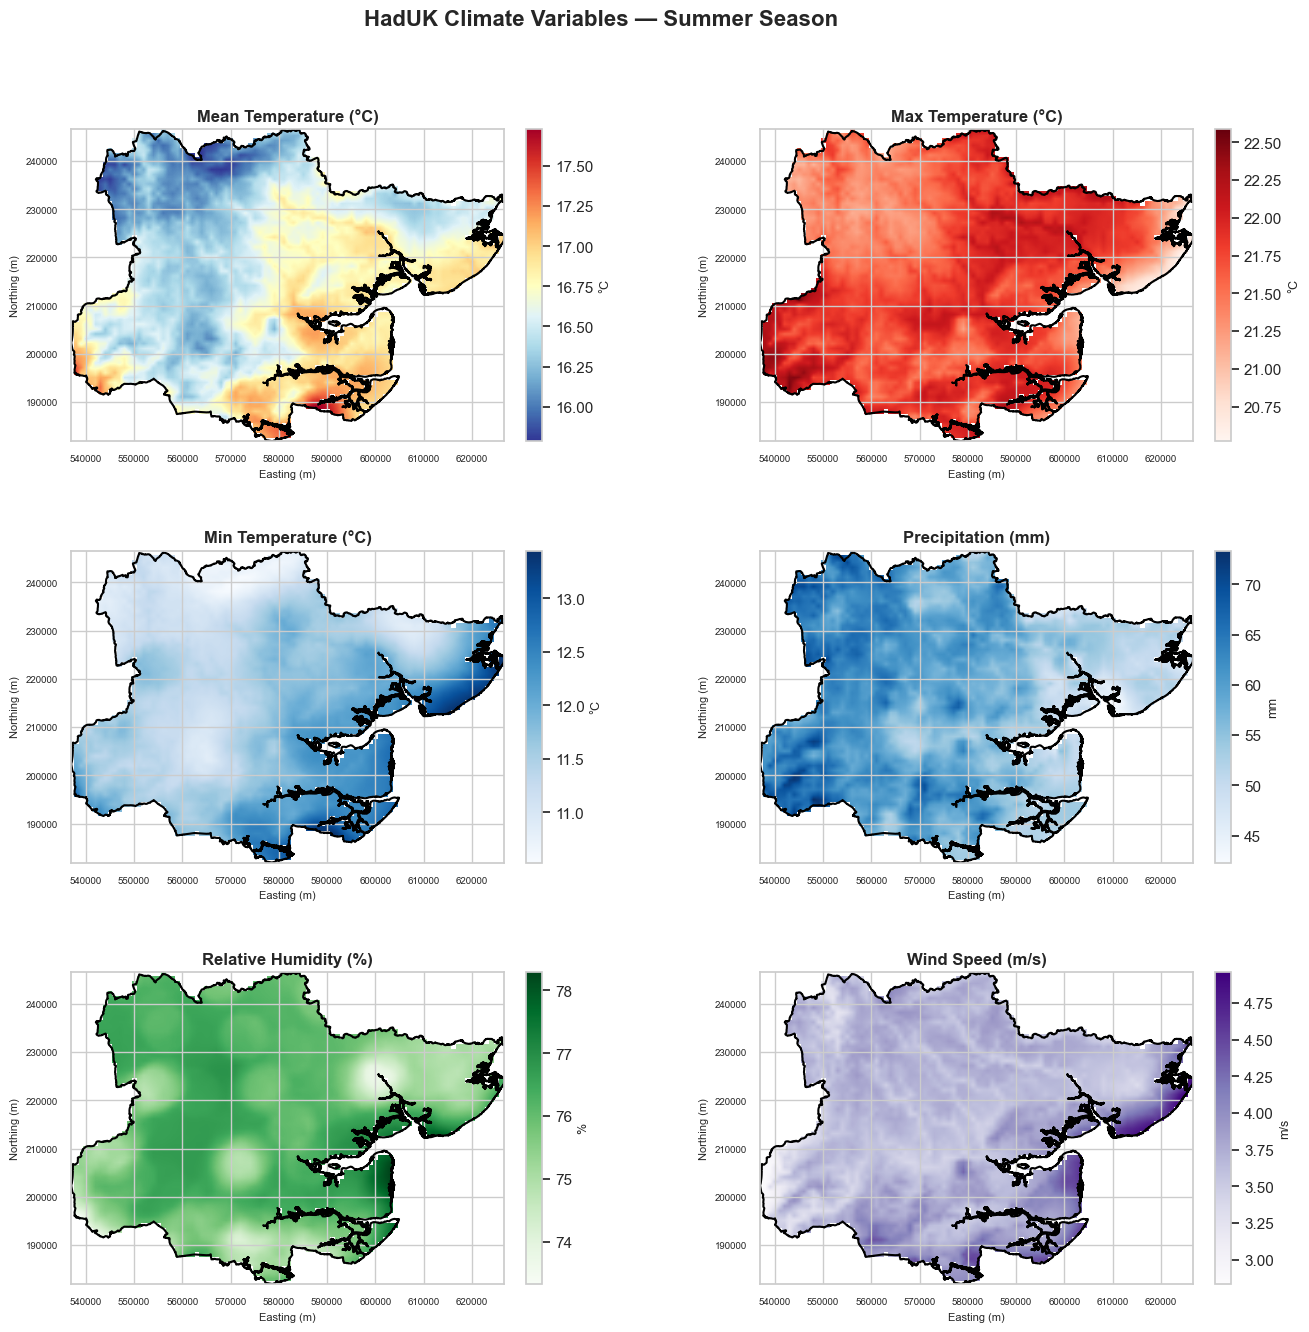

In [37]:
climate_vars = [
    ("meteo_tas_summer.tif", "Mean Temperature (°C)", "RdYlBu_r"),
    ("meteo_tasmax_summer.tif", "Max Temperature (°C)", "Reds"),
    ("meteo_tasmin_summer.tif", "Min Temperature (°C)", "Blues"),
    ("meteo_rainfall_summer.tif", "Precipitation (mm)", "Blues"),
    ("meteo_hurs_summer.tif", "Relative Humidity (%)", "Greens"),
    ("meteo_sfcWind_summer.tif", "Wind Speed (m/s)", "Purples"),
]

plot_raster_group(climate_vars, "HadUK Climate Variables — Summer Season", "03_climate_maps_summer")

Saved: 06_fire_veg_maps.png


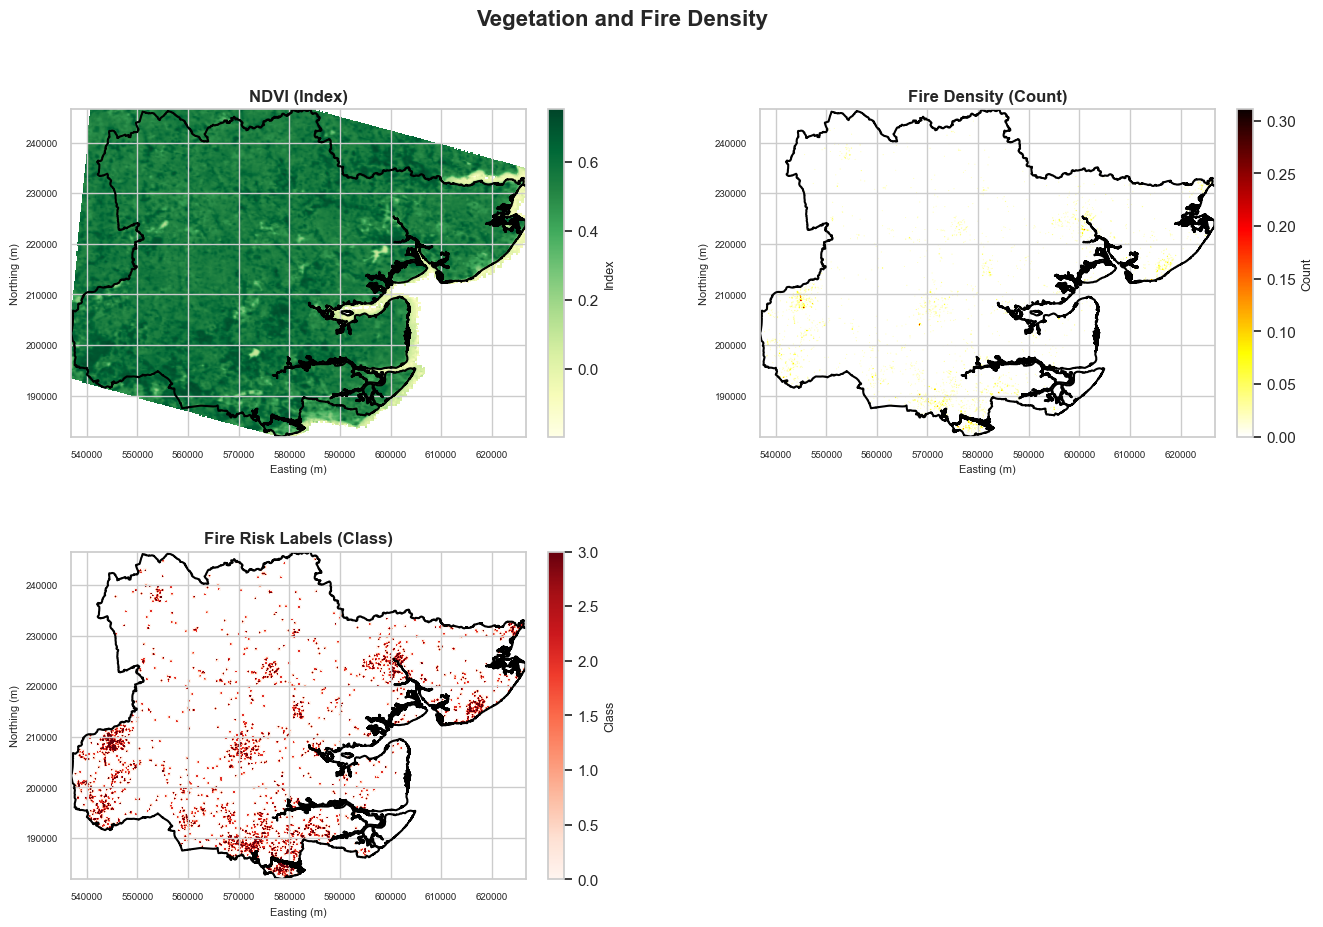

In [38]:
veg_fire_vars = [
    ("ndvi.tif", "NDVI (Index)", "YlGn"),
    ("fire_density_summer.tif", "Fire Density (Count)", "hot_r"),
    ("risk_labels_summer.tif", "Fire Risk Labels (Class)", "Reds")
]

plot_raster_group(veg_fire_vars, "Vegetation and Fire Density", "06_fire_veg_maps")

# individual

In [39]:
def save_individual_plots(var_list, output_subfolder="individual_maps"):
    """
    Generates and saves individual maps for a list of spatial variables
    without displaying them in the notebook.
    
    Parameters:
    - var_list: List of tuples (filename, title, colormap)
    - output_subfolder: Optional subfolder within OUTPUT_DIR to keep things tidy
    """
    boundary = gpd.read_file(BOUNDARY_PATH).to_crs("EPSG:27700")
    
    # Create a subfolder to prevent cluttering the main output directory
    save_dir = OUTPUT_DIR / output_subfolder
    save_dir.mkdir(parents=True, exist_ok=True)
    
    for filename, title, cmap in var_list:
        path = LAYERS_DIR / filename
        
        if not path.exists():
            print(f"Skipping {filename}: File not found.")
            continue
            
        # Create a single figure for this specific variable
        fig, ax = plt.subplots(figsize=(8, 6))
        
        with rasterio.open(path) as src:
            data = src.read(1)
            bounds = src.bounds
            
        # Plot raster and boundary
        im = ax.imshow(data, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
                       cmap=cmap, interpolation="nearest", origin="upper")
        boundary.boundary.plot(ax=ax, color="black", linewidth=1.5)
        
        # Format colorbar
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar_label = title.split("(")[1].rstrip(")") if "(" in title else "Value"
        cbar.set_label(cbar_label, fontsize=9)
        
        # Format axes
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("Easting (m)", fontsize=8)
        ax.set_ylabel("Northing (m)", fontsize=8)
        ax.tick_params(labelsize=7)
        
        # Construct the output filename (e.g., meteo_tas_summer.png)
        out_name = filename.replace('.tif', '.png').replace('.gpkg', '.png')
        output_path = save_dir / out_name
        
        # Save the figure
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {output_path.name}")
        
        # CRITICAL: Close the figure to suppress inline display in the notebook
        plt.close(fig)

In [40]:
# Assuming you already defined climate_vars, topo_vars, etc. from the previous step

print("Processing Climate Variables...")
save_individual_plots(climate_vars, output_subfolder="climate")

print("\nProcessing Topography Variables...")
save_individual_plots(topo_vars, output_subfolder="topography")

print("\nProcessing Infrastructure Variables...")
save_individual_plots(dist_vars, output_subfolder="infrastructure")

print("\nProcessing Vegetation/Fire Variables...")
save_individual_plots(veg_fire_vars, output_subfolder="vegetation_and_fire")

print("\nAll individual maps generated successfully.")

Processing Climate Variables...
Saved: meteo_tas_summer.png
Saved: meteo_tasmax_summer.png
Saved: meteo_tasmin_summer.png
Saved: meteo_rainfall_summer.png
Saved: meteo_hurs_summer.png
Saved: meteo_sfcWind_summer.png

Processing Topography Variables...
Saved: topo_elevation.png
Saved: topo_slope.png
Saved: topo_aspect.png

Processing Infrastructure Variables...
Saved: dist_activity.png
Saved: dist_rivers.png
Saved: dist_roads.png

Processing Vegetation/Fire Variables...
Saved: ndvi.png
Saved: fire_density_summer.png
Saved: risk_labels_summer.png

All individual maps generated successfully.
